# PyTorch Autograd

In [1]:
!pip install mlxtend torchviz > /dev/null 2>&1

In [ ]:
%matplotlib inline
import torch
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

# Check available hardware
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'GPU is available, using {device}')
elif torch.mps.is_available():
    device = torch.device('mps')
    print(f'Apple Metal Performance Shaders framework is available, using {device}')
else:
    device = torch.device('cpu')
    print(f'Hardware acceleration not available, using {device}')

tkwargs = {'dtype': torch.float, 'device': device} # For tensor initialization

Apple Metal Performance Shaders framework is available, using mps


## Basics of PyTorch Autograd

- Tensors and gradient tracking
- Leaf nodes
- Root nodes
- Computation graphs and gradient functions

In [4]:
x = torch.tensor([2., 3.], requires_grad=True, **tkwargs)
y = torch.tensor([1., 2.], requires_grad=True, **tkwargs)
c = torch.tensor([3., 4.], requires_grad=True, **tkwargs)

print(f"x: {x}\ny: {y}\nc: {c}")

x: tensor([2., 3.], device='mps:0', requires_grad=True)
y: tensor([1., 2.], device='mps:0', requires_grad=True)
c: tensor([3., 4.], device='mps:0', requires_grad=True)


In [7]:
z = x * y + c
print(f"z: {z}")

loss = torch.mean(torch.rand(z.shape, **tkwargs) - z).pow(2)
print(f"loss: {loss}")

z: tensor([ 5., 10.], device='mps:0', grad_fn=<AddBackward0>)
loss: 52.965965270996094


In [10]:
for name, tensor in zip(['x', 'y', 'c', 'z', 'loss'], [x, y, c, z, loss]):
    print(f"Is {name} a leaf tensor: {tensor.is_leaf}\t{tensor}")


Is x a leaf tensor: True	tensor([2., 3.], device='mps:0', requires_grad=True)
Is y a leaf tensor: True	tensor([1., 2.], device='mps:0', requires_grad=True)
Is c a leaf tensor: True	tensor([3., 4.], device='mps:0', requires_grad=True)
Is z a leaf tensor: False	tensor([ 5., 10.], device='mps:0', grad_fn=<AddBackward0>)
Is loss a leaf tensor: False	52.965965270996094


In [39]:
# Create a tensor and set requires_grad=True to track its gradients
x = torch.tensor([2.0, 3.0], requires_grad=True, **tkwargs)
y = torch.tensor([1.0, 2.0], requires_grad=True, **tkwargs)
c = torch.tensor([3.0, 4.0], requires_grad=True, **tkwargs)

# step 1: multiply x and y
r1 = torch.mul(x, y)
# step 2: add r1 with c
w = torch.add(r1, c)
# step 3: Take mean of w
z = torch.mean(w)

for name, tensor in zip(['x', 'y', 'c', 'r1', 'w', 'z'], [x, y, c, r1, w, z]):
    print(f"Is {name} a leaf tensor: {tensor.is_leaf}\t{tensor}")


Is x a leaf tensor: True	tensor([2., 3.], device='mps:0', requires_grad=True)
Is y a leaf tensor: True	tensor([1., 2.], device='mps:0', requires_grad=True)
Is c a leaf tensor: True	tensor([3., 4.], device='mps:0', requires_grad=True)
Is r1 a leaf tensor: False	tensor([2., 6.], device='mps:0', grad_fn=<MulBackward0>)
Is w a leaf tensor: False	tensor([ 5., 10.], device='mps:0', grad_fn=<AddBackward0>)
Is z a leaf tensor: False	7.5


In [40]:
z.backward()
for name, tensor in zip(['x', 'y', 'c'], [x, y, c]):
    print(f'gradient of {name}: {tensor.grad.tolist()}')

gradient of x: [0.5, 1.0]
gradient of y: [1.0, 1.5]
gradient of c: [0.5, 0.5]


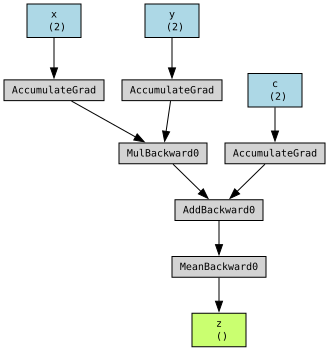

In [41]:
import torchviz
torchviz.make_dot(z, {'x': x, 'y': y, 'c': c, 'z': z, 'w': w, 'r1': r1})

In [42]:
z.backward()

RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

In [43]:
r1.grad

/var/folders/f4/zmz5gq0x5d95rv5fy_xcpxz00000gn/T/ipykernel_66983/4243421823.py:1: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /Users/runner/work/pytorch/pytorch/build/aten/src/ATen/core/TensorBody.h:498.)
  r1.grad


## Another example

\begin{align*}
    Q &= 3 a^3 - b^2 \\
\end{align*}

\begin{align*}
    \frac{\partial Q}{\partial a} &= 9 a^2 \\
    \frac{\partial Q}{\partial b} &= -2 b \\
\end{align*}

In [57]:
a = torch.tensor([2., 3.], requires_grad=True, **tkwargs)
b = torch.tensor([6., 4.], requires_grad=True, **tkwargs)

Q = 3 * a**3 - b**2
print(Q.shape)

torch.Size([2])


In [58]:
gradient = torch.tensor([1., 1.], **tkwargs)
Q.retain_grad()
Q.backward(gradient=gradient)

In [60]:
print(9*a**2 == a.grad)
print(-2*b == b.grad)

tensor([True, True], device='mps:0')
tensor([True, True], device='mps:0')


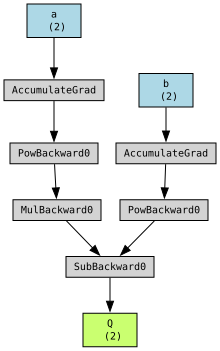

In [64]:
torchviz.make_dot(Q, params={'a': a, 'b': b, 'Q': Q})

## Another example: loss computation and gradient tracking

\begin{align*}
    z &= w \, x + b \\
    L &= (y - z)^2
\end{align*}

\begin{align*}
    \frac{\partial L}{\partial w} &= 2 x\,(z-y) \\
    \frac{\partial L}{\partial b} &= 2 (z-y)
\end{align*}

In [71]:
w = torch.tensor(1., requires_grad=True)
b = torch.tensor(0., requires_grad=True)

x = torch.tensor([0.5])
y = torch.tensor([6.8])

z = w * x + b
loss = (y - z).pow(2).sum()
loss.backward()

print(f'dL/dw = {w.grad}, should be {2*x*(z - y)}')
print(f'dL/db = {b.grad}, should be {2*(z - y)}')

dL/dw = -6.300000190734863, should be tensor([-6.3000], grad_fn=<MulBackward0>)
dL/db = -12.600000381469727, should be tensor([-12.6000], grad_fn=<MulBackward0>)


## Using this in a torch neural network

In [44]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class NN(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(1, 4)
        self.fc2 = nn.Linear(4, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.tanh(self.fc2(x))
        return x

model = NN()
inputs = torch.rand(1)
outputs = model(inputs)

print(f"Inputs:  {inputs}")
print(f"Outputs: {outputs}")

Inputs:  tensor([0.6509])
Outputs: tensor([0.4628], grad_fn=<TanhBackward0>)


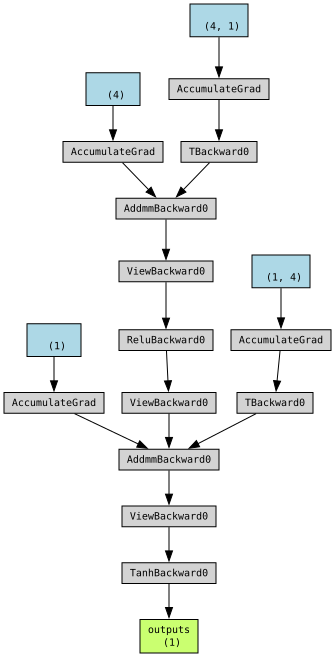

In [46]:
import torchviz
torchviz.make_dot(outputs, {'inputs': inputs, 'outputs': outputs})

## Comparing different ways to compute gradients

\begin{equation*}
    \sigma(x) = \frac{1}{1 + e^{-x}}
\end{equation*}

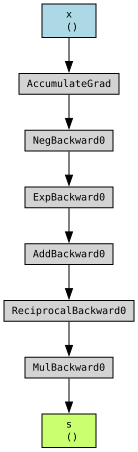

In [74]:
def sigmoid(x):
    return 1. / (1. + torch.exp(-x))

x = torch.tensor(1., requires_grad=True)
s = sigmoid(x)

torchviz.make_dot(s, params={'x': x, 's': s})

\begin{align}
    a(z) &= -z \\
    b(a) &= e^a \\
    c(b) &= 1 + b \\
    d(c) &= 1 / c \\
\end{align}

In [ ]:
def grad_sigmoid_analytic(x):
    z = sigmoid(x)
    return z * (1 - z)

def grad_sigmoid_pytorch(x):
    z = sigmoid(x)
    z.backward()
    return x.grad

def grad_sigmoid_reverse_mode(x):
    a = -x
    b = np.exp(a)
    c = 1 + b
    d = 1 / c

    dddc = -1. / c**2
    dddb = dddc * 1
    ddda = dddb * np.exp(a)
    dddx = -ddda

    return dddx

def grad_sigmoid_forward_mode(x):
    """ Another option is to compute gradients during the forward pass """
    a = -x
    dadx = -1.

    b = np.exp(a)
    dbda = np.exp(a)

    c = 1 + b
    dcdb = 1.

    d = 1/c
    dddc = -1. / c**2

    return dddc * dcdb * dbda * dadx    

x = torch.tensor(1., requires_grad=True)
print(f"Analytical derivative: {grad_sigmoid_analytic(x)}")
print(f"PyTorch Autograd: {grad_sigmoid_pytorch(x)}")
print(f"Manual Reverse-Mode: {grad_sigmoid_reverse_mode(x.detach().numpy())}")
print(f"Manual Forward-Mode: {grad_sigmoid_forward_mode(x.detach().numpy())}")

Analytical derivative: 0.1966119259595871
PyTorch Autograd: 0.1966119408607483
Manual Reverse-Mode: 0.19661197066307068
Manual Forward-Mode: 0.19661197066307068


## Manually coding a 1-hidden layer NN

In [104]:
def sigmoid(x):
    return 1. / (1. + torch.exp(-x))

def grad_sigmoid(z):
    return z * (1 - z)

def relu(x):
    return torch.maximum(x, torch.tensor(0.))

def grad_relu(x):
    return torch.where(x > 0, torch.tensor(1.), torch.tensor(0.))

def forward(x, w1, w2):
    z1 = x @ w1.T # [B, I] x [I, H]
    h1 = relu(z1)

    z2 = h1 @ w2.T # [B, H] x [H, O]
    h2 = sigmoid(z2)

    return h2, z1, h1, z1

def backward_autograd(x, w1, w2, y):
    x.requires_grad_(True)
    w1.requires_grad_(True)
    w2.requires_grad_(True)

    y_pred, _, _, _ = forward(x, w1, w2)
    loss = (y_pred - y).pow(2).mean()
    loss.backward()

    return w1.grad, w2.grad

def backward_manual(x, w1, w2, y):
    h2, z2, h1, z1 = forward(x, w1, w2)
    loss = (h2 - y).pow(2).mean()

    dloss_dh2 = 2 * (h2 - y) * y.numel() # [B, O]
    dloss_dz2 = dloss_dh2 * grad_sigmoid(h2) # [B, O]

    dloss_dw2 = dloss_dz2.T @ h1 # [O, B] x [B, H]

    dloss_dh1 = dloss_dz2 @ w2 # [B, O] x [O, H]
    dloss_dz1 = dloss_dh1 * grad_relu(z1) # [B, H]

    dloss_dw1 = dloss_dz1.T @ x # [H, B] x [B, I]

    return dloss_dw1, dloss_dw2


x = torch.rand([1, 2]) #[B, I]
w1 = torch.rand([4, 2]) #[H, I]
w2 = torch.rand([1, 4]) #[O, H]
y = torch.rand(1) #[]

print("With autograd:")
w1_grad, w2_grad = backward_autograd(x, w1, w2, y)
print(f'w1_grad = {w1_grad}')
print(f'w2_grad = {w2_grad}')

print('-------------')
print('Manually (reverse-mode):')
w1_grad, w2_grad = backward_manual(x, w1, w2, y)
print(f'w1_grad = {w1_grad}')
print(f'w2_grad = {w2_grad}')


With autograd:
w1_grad = tensor([[-0.0099, -0.0928],
        [-0.0008, -0.0078],
        [-0.0041, -0.0386],
        [-0.0067, -0.0625]])
w2_grad = tensor([[-0.0303, -0.0066, -0.0746, -0.0388]])
-------------
Manually (reverse-mode):
w1_grad = tensor([[-0.0099, -0.0928],
        [-0.0008, -0.0078],
        [-0.0041, -0.0386],
        [-0.0067, -0.0625]], grad_fn=<MmBackward0>)
w2_grad = tensor([[-0.0303, -0.0066, -0.0746, -0.0388]], grad_fn=<MmBackward0>)


Note that we're doing this "reverse-mode automatic differentiation" by starting with derivatives from the loss and propagating backward. 

\begin{align*}
    \frac{\partial L}{\partial w_1} &\sim \frac{\partial L}{\partial z_2} \frac{\partial z_2}{\partial z_1} \frac{\partial z_1}{\partial w_1}
\end{align*}

That is, we're performing the above operation from left to right. For a single example, the size of each tensor is

\begin{align*}
    &\sim \bigg( \underbrace{\frac{\partial L}{\partial z_2}}_{1 \times O} \cdot \underbrace{\frac{\partial z_2}{\partial z_1}}_{O \times H} \bigg) \underbrace{\frac{\partial z_1}{\partial w_1}}_{H \times I}
\end{align*}

Thus, the total number of operations here is $H \, O + H\, I = H (O + I)$

Another way to do it would be to do "forward-mode automatic differentiation," which performs the above operation from right to left. 

\begin{align*}
    &\sim \underbrace{\frac{\partial L}{\partial z_2}}_{1 \times O} \bigg( \underbrace{\frac{\partial z_2}{\partial z_1}}_{O \times H} \cdot \underbrace{\frac{\partial z_1}{\partial w_1}}_{H \times I} \bigg)
\end{align*}

Here, the total number of operations is $O\,H\,I + O\,I = O\,I(1 + H)$

## Autograd can compute derivatives of functions for us

In [ ]:
x = torch.linspace(0, 2.*torch.pi, 100, requires_grad=True)
z = torch.sin(x)
dz_dx = torch.autograd.grad(
    outputs=z,
    inputs=x,
    grad_outputs=torch.ones_like(z), # dz/dz = 1
    create_graph=True # We want to create a computation graph
)[0]

tensor([ 1.0000,  0.9980,  0.9920,  0.9819,  0.9679,  0.9501,  0.9284,  0.9029,
         0.8738,  0.8413,  0.8053,  0.7660,  0.7237,  0.6785,  0.6306,  0.5801,
         0.5272,  0.4723,  0.4154,  0.3569,  0.2969,  0.2358,  0.1736,  0.1108,
         0.0476, -0.0159, -0.0793, -0.1423, -0.2048, -0.2665, -0.3271, -0.3863,
        -0.4441, -0.5000, -0.5539, -0.6056, -0.6549, -0.7015, -0.7453, -0.7861,
        -0.8237, -0.8580, -0.8888, -0.9161, -0.9397, -0.9595, -0.9754, -0.9874,
        -0.9955, -0.9995, -0.9995, -0.9955, -0.9874, -0.9754, -0.9595, -0.9397,
        -0.9161, -0.8888, -0.8580, -0.8237, -0.7861, -0.7453, -0.7015, -0.6549,
        -0.6056, -0.5539, -0.5000, -0.4441, -0.3863, -0.3271, -0.2665, -0.2048,
        -0.1423, -0.0792, -0.0159,  0.0476,  0.1108,  0.1736,  0.2358,  0.2969,
         0.3569,  0.4154,  0.4723,  0.5272,  0.5801,  0.6306,  0.6785,  0.7237,
         0.7660,  0.8053,  0.8413,  0.8738,  0.9029,  0.9284,  0.9501,  0.9679,
         0.9819,  0.9920,  0.9980,  1.00

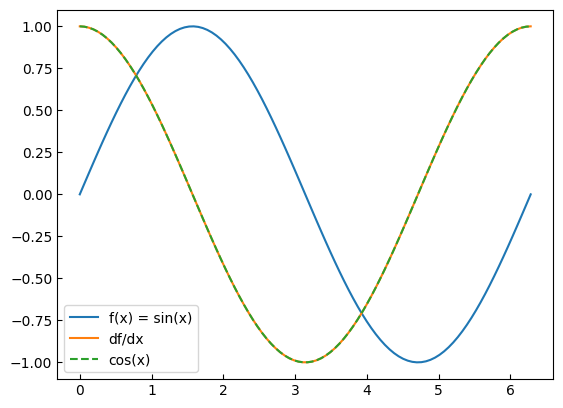

In [112]:
ax = plt.figure().gca()
ax.plot(x.detach().cpu().numpy(), z.detach().cpu().numpy(), label='f(x) = sin(x)')
ax.plot(x.detach().cpu().numpy(), dz_dx.detach().cpu().numpy(), label='df/dx')
ax.plot(x.detach().cpu().numpy(), torch.cos(x).detach().cpu().numpy(), label='cos(x)', linestyle='--')
ax.legend();

## This framework extends pretty far, for example to 2D images

In [124]:
x = torch.linspace(0., 2. * torch.pi, 100, requires_grad=False)
y = torch.linspace(0., 2. * torch.pi, 100, requires_grad=False)

X, Y = torch.meshgrid(x, y, indexing='xy')
X.requires_grad = True
Y.requires_grad = True

V = X + Y
V.retain_grad()

Z = torch.sin(V)
Z.retain_grad()

Z.backward(gradient=torch.ones_like(Z))

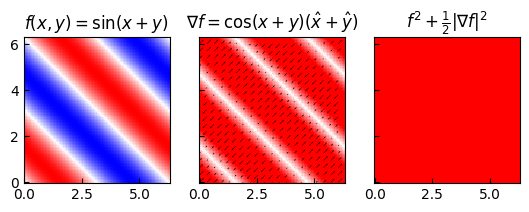

In [136]:
plt.rcParams['image.origin'] = 'lower'

with torch.no_grad():
    fig, ax = plt.subplots(1, 3, sharex=True, sharey=True)

    ax[0].pcolormesh(X, Y, Z, cmap='bwr', vmin=-1, vmax=1)
    ax[0].set_title('$f(x, y) = \\sin(x + y)$')

    dz_dx = X.grad
    dz_dy = Y.grad

    grad_Z = torch.sqrt(dz_dx**2 + dz_dy**2)
    skip = 5
    ax[1].pcolormesh(X, Y, grad_Z, cmap='bwr', vmin=-1, vmax=1)
    ax[1].quiver(X[::skip, ::skip], Y[::skip, ::skip], dz_dx[::skip, ::skip], dz_dy[::skip, ::skip])
    ax[1].set_title('$\\nabla f = \\cos(x + y) (\\hat{x} + \\hat{y})$')

    ax[2].pcolormesh(X, Y, Z**2 + 0.5 * grad_Z**2, cmap='bwr', vmin=-1, vmax=1)
    ax[2].set_title('$f^2 + \\frac{1}{2} |\\nabla f|^2$')

    for a in ax.flatten():
        a.set(aspect='equal')

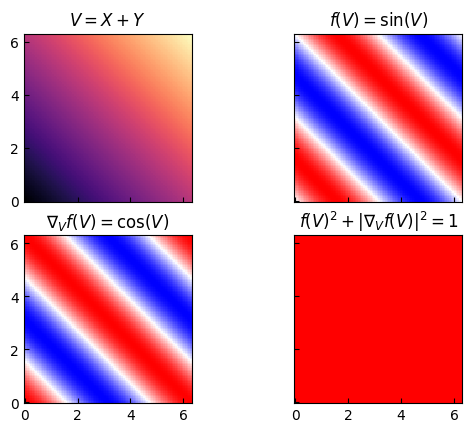

In [143]:
with torch.no_grad():
    fig, ax = plt.subplots(2, 2, sharex=True, sharey=True)

    ax[0,0].pcolormesh(X, Y, V, cmap='magma')
    ax[0,0].set_title('$V = X + Y$')

    ax[0,1].pcolormesh(X, Y, Z, cmap='bwr', vmin=-1, vmax=1)
    ax[0,1].set_title('$f(V) = \\sin(V)$')

    dz_dv = V.grad
    ax[1,0].pcolormesh(X, Y, dz_dv, cmap='bwr', vmin=-1, vmax=1)
    ax[1,0].set_title('$\\nabla_V f(V) = \\cos(V)$')

    ax[1,1].pcolormesh(X, Y, Z**2 + dz_dv**2, cmap='bwr', vmin=-1, vmax=1)
    ax[1,1].set_title('$f(V)^2 + |\\nabla_V f(V)|^2 = 1$')

    for a in ax.flatten():
        a.set(aspect='equal')

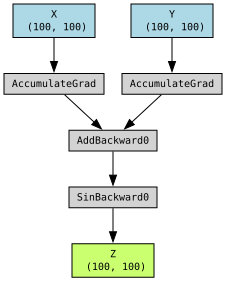

: 

In [ ]:
torchviz.make_dot(Z, params={'X': X, 'Y': Y, 'V': V, 'Z': Z})